# Experiment 6 — K-Means Clustering

**Dataset:** Fruits Dataset (Images) (Kaggle)

**Objective:** Use K-Means clustering for image compression by reducing the image color palette.

> Kaggle setup: Add the dataset listed above to the notebook. The code automatically searches `/kaggle/input` for the required files/folders where possible.

In [1]:

import os, glob, warnings
warnings.filterwarnings("ignore")


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

## 1. Locate an image from the Kaggle Fruits Dataset

In [3]:
image_exts = {".jpg",".jpeg",".png",".bmp",".webp"}
image_paths = []
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if os.path.splitext(f)[1].lower() in image_exts:
            image_paths.append(os.path.join(root,f))

if not image_paths:
    raise FileNotFoundError("Add a Kaggle image dataset such as 'Fruits Dataset (Images)'.")

# Pick the first image automatically.
image_path = image_paths[0]
print("Using image:", image_path)
img = Image.open(image_path).convert("RGB")
img.thumbnail((500,500))
img = np.array(img)
print("Image shape:", img.shape)

Using image: /kaggle/input/datasets/shreyapmaher/fruits-dataset-images/images/apple fruit/Image_22.jpg
Image shape: (375, 500, 3)


## 2. K-Means image compression

In [4]:
pixels = img.reshape(-1, 3).astype(np.float32)

# Small sample for fitting keeps Kaggle runtime fast.
rng = np.random.default_rng(42)
sample_size = min(20000, len(pixels))
sample_idx = rng.choice(len(pixels), sample_size, replace=False)

k = 8
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
kmeans.fit(pixels[sample_idx])

compressed_pixels = kmeans.predict(pixels)
compressed = kmeans.cluster_centers_[compressed_pixels].reshape(img.shape).astype(np.uint8)

print(f"Original colors: potentially {len(np.unique(pixels, axis=0)):,}")
print(f"Compressed palette size: {k}")

Original colors: potentially 122,731
Compressed palette size: 8


## 3. Compare original and compressed images

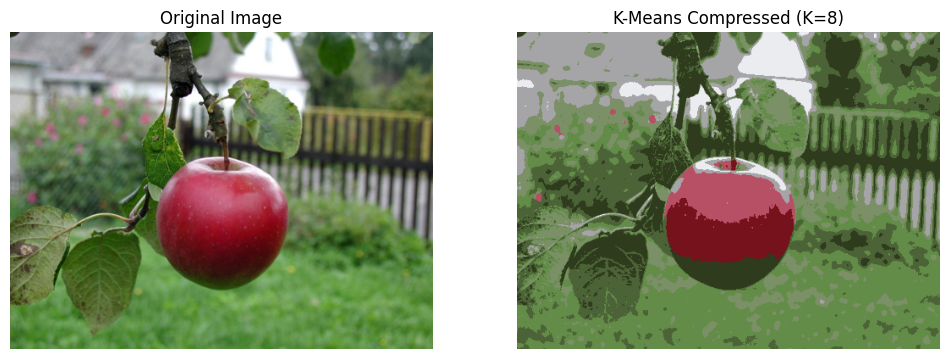

In [5]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(compressed)
plt.title(f"K-Means Compressed (K={k})")
plt.axis("off")
plt.show()

## 4. Save compressed image

In [6]:
Image.fromarray(compressed).save("/kaggle/working/compressed_kmeans.png")
print("Saved: /kaggle/working/compressed_kmeans.png")

Saved: /kaggle/working/compressed_kmeans.png
